In [1]:
#IMPORTS
import pandas as pd
import numpy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#READING DATA
df = pd.read_csv('breast_cancer_enhanced_dataset.csv')
# print(df.shape)
# print(df.columns)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
0,5.683796e+06,B,11.829858,21.726166,75.154378,435.022394,0.087089,0.050717,0.015868,0.011641,0.078226,0.000185,0.026075,257.017451,0.187718,0.000036,22.433798
1,-6.253379e+06,B,10.991150,17.103260,71.798929,381.386295,0.089339,0.109498,0.097344,0.035629,0.242470,0.003468,0.080823,187.984489,1.069921,0.000255,24.021839
2,4.213892e+06,M,21.433519,15.092437,142.753006,1392.399890,0.099557,0.152079,0.193372,0.126922,0.472373,0.024543,0.157458,323.484034,4.144647,0.000139,49.053992
3,-2.986069e+06,B,11.700452,14.872127,74.154481,404.112556,0.101291,0.077563,0.043749,0.028747,0.150059,0.001258,0.050020,174.010599,0.511885,0.000108,23.276145
4,6.469594e+05,B,13.259377,17.212990,83.621014,521.124238,0.072905,0.043312,0.046983,0.010096,0.100391,0.000474,0.033464,228.233523,0.622960,0.000090,25.647074


Notes:
B - Benign
M - Malignant


Columns:
   'id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
   'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
   'concave points_mean', 'shape_irregularity', 'border_complexity',
   'tumor_aggressiveness', 'radius_texture_interaction',
   'radius_concavity_interaction', 'concavity_density',
   'malignancy_risk_score'


Attempted to create a heatmap didnt work because the 'diagnosis' column contained string
Using one hot encoding to resolve


DATA SCRUBBING

=== Part A: Feature Selection
all of the features seems to be important or at the very least indiscernable for what is and isn't important due to their vague column names

to figure out what is important I attempted to make a heatmap
but it failed since the diagnosis column contained a string
using one hot encoding should resolve it

after using one hot encoding I'm considering dropping the following:
malignancy_risk_score - 10
concavity_mean - 7
concave points_mean - 10
shape_irregularity - 7
border_complexity - 7
tumor_agressiveness - 7
radius_concavity_interaction - 10 


=== Part B:Row Compression


In [3]:
df = pd.get_dummies(df, columns=['diagnosis'])
df.head()

df_corr = df.corr()
# sns.heatmap(df_corr, annot=True, cmap = 'coolwarm')

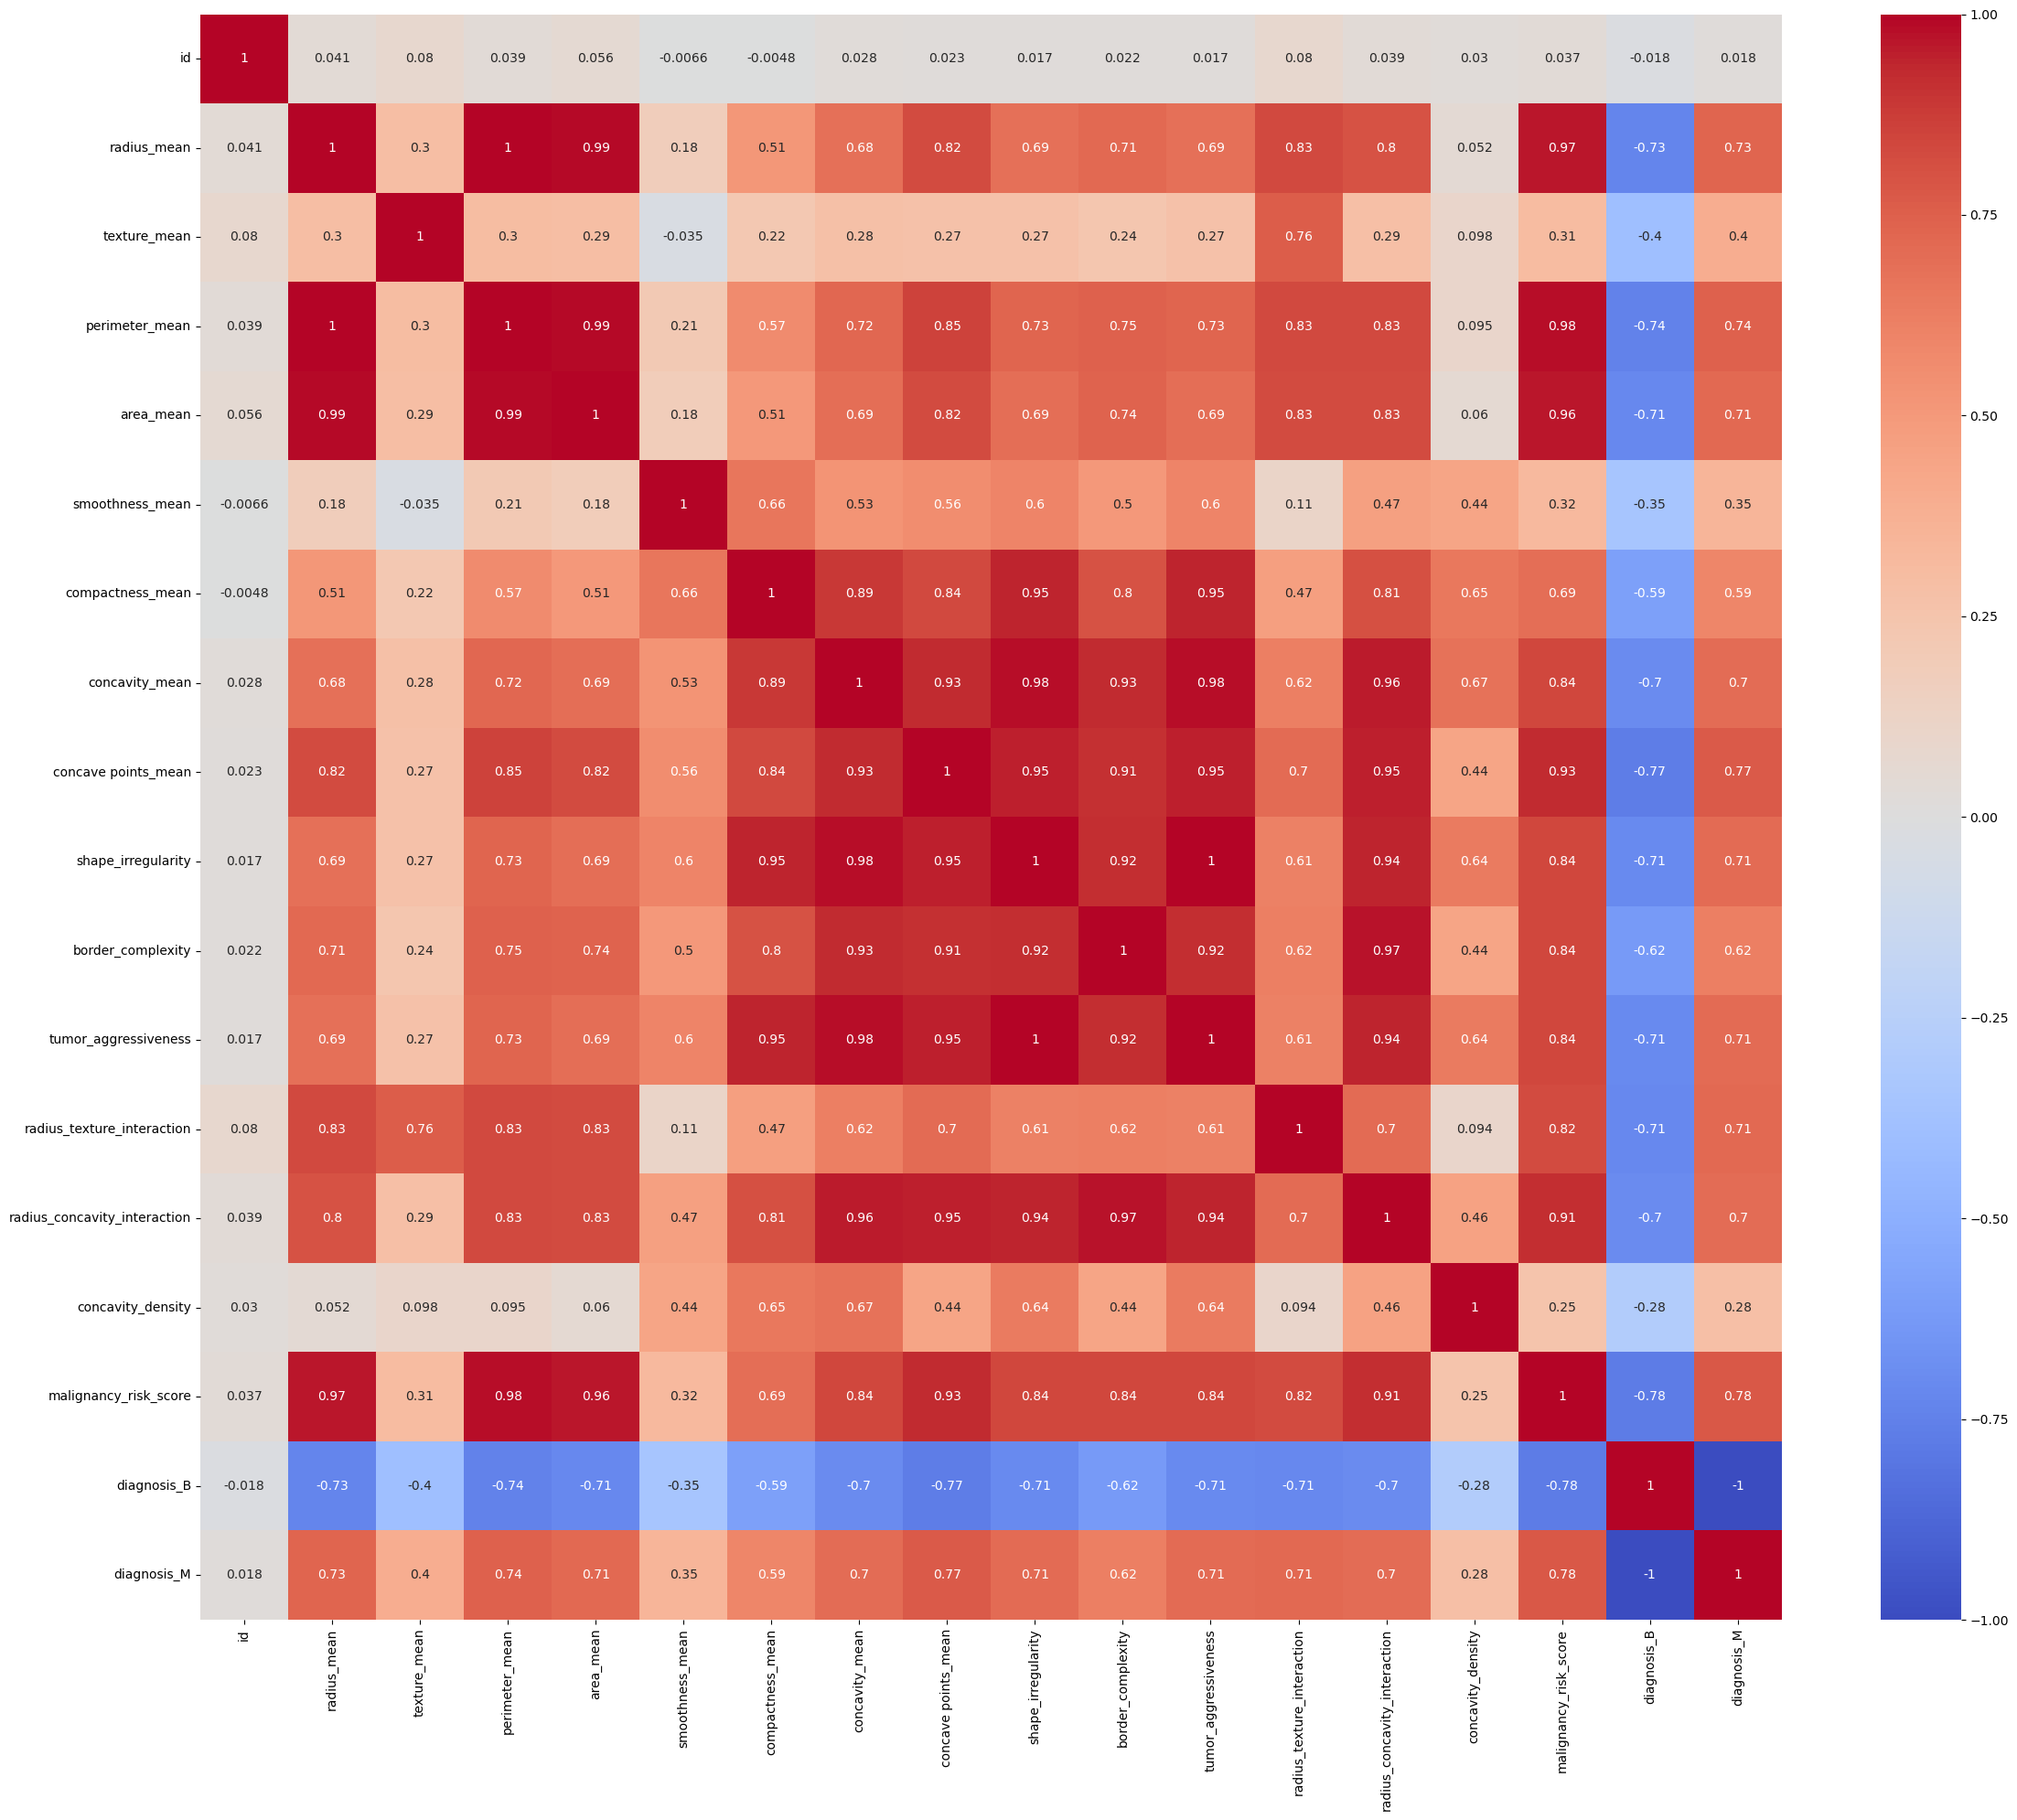

In [4]:
plt.figure(figsize=(24, 20))  # Scale up based on feature count
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

In [ ]:
# stores the df prior to dropping columns
original_df = df

#drops columns that had strong correlations with more than 10 features
df = df.drop(columns=['id', 'radius_concavity_interaction','concave points_mean','malignancy_risk_score', 'diagnosis_M'], axis = 1)

In [10]:
print(df.columns)

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'shape_irregularity', 'border_complexity', 'tumor_aggressiveness',
       'radius_texture_interaction', 'concavity_density', 'diagnosis_B'],
      dtype='object')


In [11]:
# SET X AND Y VARIABLES
y = df['diagnosis_B']
x = df.drop(columns=['diagnosis_B'], axis = 1)


In [12]:
#SHUFFLE + SPLIT DATA
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 10, shuffle=True)

In [15]:
#SET ALGORITHM

#first attempt here couldn't reach a convergence 
# model = LogisticRegression()
# model.fit(x_train, y_train)

#second attempt raise the allowed number of iterations to 1000 instead of defaulted 100
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
#EVALUATE
model_predict = model.predict(x_test)

In [17]:
#CONFUSION MATRIX
print(confusion_matrix(y_test, model_predict))

[[538  77]
 [ 42 993]]


First attempt outputted this:

[[538  77]
 [ 42 993]]

 [[TP, FN]
  [FP, TN]]

538 true positives
77 false negatives
42 false positives
993 true negatives

accuracy is 0.9278 or 92.78 %

In [18]:
#CLASSIFICATION REPORT
print(classification_report(y_test, model_predict))

              precision    recall  f1-score   support

       False       0.93      0.87      0.90       615
        True       0.93      0.96      0.94      1035

    accuracy                           0.93      1650
   macro avg       0.93      0.92      0.92      1650
weighted avg       0.93      0.93      0.93      1650



In [19]:
df.shape
original_df.shape

(5500, 18)

This section tests what would happen if we never removed any features
except for id 

In [20]:
original_df.columns

Index(['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'shape_irregularity', 'border_complexity',
       'tumor_aggressiveness', 'radius_texture_interaction',
       'radius_concavity_interaction', 'concavity_density',
       'malignancy_risk_score', 'diagnosis_B', 'diagnosis_M'],
      dtype='object')

In [21]:
b = df['diagnosis_B']
a = original_df.drop(columns=['id', 'diagnosis_B', 'diagnosis_M'], axis = 1)

In [27]:
a_train, a_test, b_train, b_test  = train_test_split(a, b, test_size=0.3, random_state=10, shuffle=True)

In [28]:
model.fit(a_train, b_train)

LogisticRegression(max_iter=1000)

In [29]:
model_predict = model.predict(a_test)

In [30]:
print(confusion_matrix(b_test, model_predict))

[[550  65]
 [ 47 988]]


In [26]:
print(classification_report(b_test, model_predict))

              precision    recall  f1-score   support

       False       0.92      0.89      0.91       615
        True       0.94      0.95      0.95      1035

    accuracy                           0.93      1650
   macro avg       0.93      0.92      0.93      1650
weighted avg       0.93      0.93      0.93      1650

